In [28]:
import sys
sys.dont_write_bytecode = True # cacheを出さない
import numpy as np # type: ignore
from PIL import Image as im # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd
import os
import struct

In [ ]:
# hisファイルを読み込んで、np.ndarrayにする関数
def his2array(filename):
    with open(filename, 'rb') as file:
        data = file.read()
    
    # Define the keys for the header information
    keylist = [
        "ID", "headerSize", "headerVersion", "fileSize", "imageHeaderSize",
        "ULX", "ULY", "BRX", "BRY", "numberOfFrame", "correction",
        "frameTimeInMicroseconds", "frameTimeInMilliseconds"
    ]

    # Unpack the header data based on the expected structure
    info = dict(
        zip(
            keylist,
            struct.unpack('<HHHLHHHHHHHdH', data[:34])
        )
    )

    # Calculate the image dimensions
    imageWidth = info["BRX"] - info["ULX"] + 1
    imageHeight = info["BRY"] - info["ULY"] + 1

    # Calculate the starting position of the image data
    start_position = info["headerSize"] + info["imageHeaderSize"]

    # Extract all image data as a numpy array
    image_data = np.frombuffer(data[start_position:], dtype=np.uint16)

    # Reshape the image data to separate frames
    sequential_image_intensities = image_data.reshape((info["numberOfFrame"], imageHeight, imageWidth))

    # Select the first frame's intensities for further processing
    img = sequential_image_intensities[0]
    return img

In [4]:
his_path = r"D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_26.his"

In [7]:
img = his2array(his_path)

C:\Users\okaza\AppData\Local\Temp\ipykernel_35208\845255229.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow((np.log(img)))


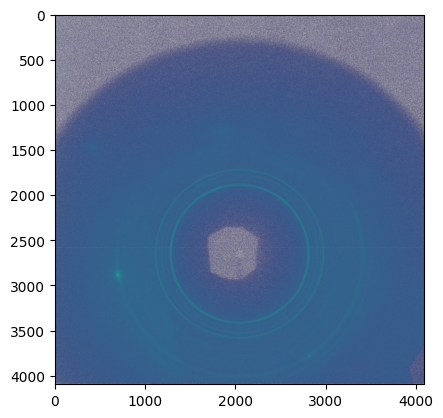

In [9]:
plt.imshow((np.log(img)))

In [11]:
poni_path = r"d:\DATA\SPring-8-2025-Nov\CeO2_20251028\IPanalyzer_FPD_MgS400_EH2_20251210_okazaki.poni"

In [12]:
import pyFAI

In [13]:
ai = pyFAI.load(poni_path)

In [15]:
tth, intensity = ai.integrate1d(
    img,
    npt = 4000,
    unit = "2th_deg",
    method = "ocl" # optional
)

(5.0, 25.0)

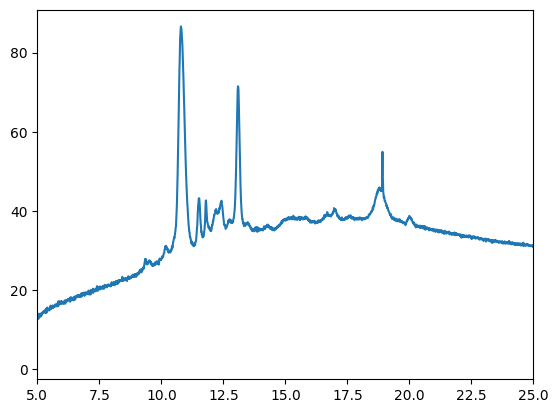

In [19]:
plt.plot(tth, intensity)
plt.xlim(5,25)

In [25]:
csvfilename = os.path.splitext(his_path)[0] + ".csv"
pd.DataFrame([tth, intensity]).T.to_csv(csvfilename, header = False, index = False)
print(os.path.abspath(csvfilename))


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_26.csv


In [20]:
dir = r"D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2"

header = "UODE32_3_"
footer = ".his"

flist = []
for _ in os.listdir(dir):
    if not header in _:
        continue
    elif not footer in _:
        continue
    flist.append(_)

flist.sort(key = (
    lambda x: int(x.replace(header, "").replace(footer, ""))
))
filenames = list(map(lambda x: os.path.join(dir, x), flist))


for f in filenames:
    print(f)

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_0.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_1.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_2.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_3.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_4.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_5.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_6.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_7.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_8.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_9.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_10.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_11.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_12.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_13.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_14.his
D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_15.his
D:\DATA\SPring-8-2

In [26]:
def make_csv(his, poni):

    img = his2array(his)

    ai = pyFAI.load(poni)

    tth, intensity = ai.integrate1d(
        img,
        npt = 4000,
        unit = "2th_deg",
        method = "ocl" # optional
    )

    csvfilename = os.path.splitext(his)[0] + ".csv"
    pd.DataFrame([tth, intensity]).T.to_csv(csvfilename, header = False, index = False)

    return csvfilename

In [27]:
for f in filenames:

    csv = make_csv(his = f, poni = poni_path)
    print(csv)

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_0.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_1.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_2.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_3.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_4.csv


...

D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_77.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_78.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_79.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_80.csv


D:\DATA\SPring-8-2025-Nov\Okazaki\UODE32\XRD2\UODE32_3_81.csv
